In [1]:
import warnings
warnings.filterwarnings('ignore')
from popsycle import synthetic
from popsycle import utils
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import synthpop

In additional to the usual python/astropy things, you'll need to install Galaxia, SPISEA, PopSyCLE.
For SPISEA, it goes faster once you've made isochrones.
Same goes from PopSyCLE with the initial-final cluster mass ratio file.

# SynthPop

This is where you generate the stellar model. Start by initializing SynthPop object with the configuration of your choice.
This may take a few minutes if it needs to download isochrones and/or several seconds to load a large extinction map file.

In [3]:
sp_mod=0 # this is here in case the model object has to be set up again, it gets mad sometimes if it already exists
sp_mod = synthpop.SynthPop('macy_defaults.synthpop_conf', # set default figuration, then set any overrides as kwargs
                           output_location="synthpop_output",  # where to place the synthpop output
                           name_for_output='test_synthpopsycle', output_filename_pattern="{name_for_output}", #how to name the output
                           post_processing_kwargs = [{"name":"ProcessDarkCompactObjects", "remove":True}, {"name": "popsycle_post_processing"}],
                           chosen_bands=["Bessell_U", "Bessell_B", "Bessell_V", "Bessell_R", "Bessell_I", "2MASS_J", "2MASS_H", "2MASS_Ks"],
                           maglim=['Bessell_U',99,'keep'],
                           extinction_map_kwargs = {"name":"galaxia_3d"}
                          )
sp_mod.init_populations()



################################ Settings #################################
# reading default parameters from
default_config_file =  /u/mhuston/code/synthpop/synthpop/config_files/_default.synthpop_conf 
# read configuration from 
config_file = '/u/mhuston/code/synthpop/synthpop/config_files/macy_defaults.synthpop_conf' 


# copy the following to a config file to redo this model generation -------
{
    "l_set": null,
    "l_set_type": null,
    "b_set": null,
    "b_set_type": null,
    "name_for_output": "test_synthpopsycle",
    "model_name": "Huston2024_NSD",
    "solid_angle": null,
    "solid_angle_unit": "deg^2",
    "random_seed": 1769873182,
    "sun": {
        "x": -8.178,
        "y": 0.0,
        "z": 0.017,
        "u": 12.9,
        "v": 245.6,
        "w": 7.78,
        "l_apex_deg": 56.24,
        "b_apex_deg": 22.54
    },
    "lsr": {
        "u_lsr": 1.8,
        "v_lsr": 233.4,
        "w_lsr": 0.53
    },
    "warp": {
        "r_warp": 7.72,
        "amp_warp":

Then, run the specific sightline you want

In [5]:
sp_mod.process_location(-3.0, 4.0, # first, enter l and b in degrees
                        solid_angle=1e-4, solid_angle_unit='deg^2', save_data=True)



############################# update location #############################
# set location to: 
l, b = (-3.00 deg, 4.00 deg)
# set solid_angle to:
solid_angle = 1.000e-04 deg^2


############################# Generate Field ##############################


# Population 0;  bulge ----------------------------------------------------
# From density profile (number density)
expected_total_iMass = 10966.5436
expected_total_eMass = 6018.5733
average_iMass_per_star = 0.5739
mass_loss_correction = 0.5488
n_expected_stars = 19109.9395
# Determine velocities when position are generated 
# From Generated Field:
generated_stars = 19126
generated_total_iMass = 10977.1107
generated_total_eMass = 5995.8215
det_mass_loss_corr = 0.5462
# Done


# Population 1;  halo -----------------------------------------------------
# From density profile (number density)
expected_total_iMass = 19.1967
expected_total_eMass = 10.1438
average_iMass_per_star = 0.5739
mass_loss_correction = 0.5284
n_expected_stars = 3

(       /popid         /vx         /vy        /vz       /rad     /glat  \
 0         0.0  -99.001826  208.955428   2.479267   3.488736  3.996897   
 1         0.0    0.737664  165.077300  32.156520   4.491198  3.996886   
 2         0.0   20.500335  187.183842 -78.504488   4.747273  4.003006   
 3         0.0  -43.326462  109.597932  44.785445   4.825497  4.003829   
 5         0.0 -190.997053   56.001455 -66.484380   5.105556  4.003990   
 ...       ...         ...         ...        ...        ...       ...   
 20303    10.0    0.381663 -197.856211  -4.951623  22.927004  3.997535   
 20304    10.0  -49.582814 -140.940266   4.561648  23.079220  4.000258   
 20305    10.0   30.187432 -172.539587  -7.280677  23.361696  4.000723   
 20306    10.0   14.294186   -3.277976   7.493797  23.530396  3.996527   
 20307    10.0    9.139244 -147.320891  -8.172207  24.293732  4.001328   
 
             /glon    /smass     /mact        /px  ...      /feh     /ubv_J  \
 0      356.997739  0.135020  0

# Population Synthesis

The stellar model now needs compact objects, which we inject with SPISEA. 
This produces an .h5 file with both stars and compact objects, sorted by latitude and longitude.
Here you can set the black hole and neutron star kick speed means, as well as the SPISEA IFMR object used to produce the compact objects.

In [6]:
synthetic.perform_pop_syn(ebf_file = 'test_synthpopsycle.ebf', 
                          output_root = 'sp_example',
                          iso_dir = '/g/lu/models/PopSyCLE_isochrones',
                          IFMR = 'SukhboldN20',
                          bin_edges_number = None, 
                          BH_kick_speed_mean = 100, 
                          NS_kick_speed_mean = 350,
                          overwrite=True);

AttributeError: 'EbfFile' object has no attribute 'elements'

# Finding microlensing events

Here is when all microlensing events are found.
You can set the survey duration, cadence, maximum impact parameter, blend radius.
This also has the option of being parallelizable.

In [6]:
synthetic.calc_events(hdf5_file = 'example.h5', 
                      output_root2 = 'example', 
                      radius_cut = 2, 
                      obs_time = 1000, 
                      n_obs = 11, 
                      theta_frac = 2, 
                      blend_rad = 0.65, 
                      overwrite = False, 
                      n_proc = 1)

Working on loop ll, bb =  0 0
Candidate events detected:  21
calc_events runtime : 16.382421 s


# Photometry

This is the last thing, where you choose the photometric band for the observations and the reddening law.
The final file of microlensing events is produced here as a .fits file.

In [7]:
synthetic.refine_events(input_root = 'example', 
                        filter_name = 'I',
                        photometric_system = 'ubv',
                        red_law = 'Damineli16', 
                        overwrite = False, 
                        output_file = 'default')

Original candidate events:  21
Candidate events in survey window:  19
refine_events runtime : 0.160328 s


# Things you can do with PopSyCLE

First, read in the table, and print out a list of all the possible keys:

In [11]:
t = Table.read('example_refined_events_ubv_I_Damineli16.fits')
print(t.colnames)

['zams_mass_L', 'mass_L', 'px_L', 'py_L', 'pz_L', 'vx_L', 'vy_L', 'vz_L', 'age_L', 'popid_L', 'exbv_L', 'glat_L', 'glon_L', 'mbol_L', 'grav_L', 'teff_L', 'feh_L', 'rad_L', 'rem_id_L', 'obj_id_L', 'ubv_J_L', 'ubv_H_L', 'ubv_K_L', 'ubv_U_L', 'ubv_I_L', 'ubv_B_L', 'ubv_V_L', 'ubv_R_L', 'vr_L', 'mu_b_L', 'mu_lcosb_L', 'zams_mass_S', 'mass_S', 'px_S', 'py_S', 'pz_S', 'vx_S', 'vy_S', 'vz_S', 'age_S', 'popid_S', 'exbv_S', 'glat_S', 'glon_S', 'mbol_S', 'grav_S', 'teff_S', 'feh_S', 'rad_S', 'rem_id_S', 'obj_id_S', 'ubv_J_S', 'ubv_H_S', 'ubv_K_S', 'ubv_U_S', 'ubv_I_S', 'ubv_B_S', 'ubv_V_S', 'ubv_R_S', 'vr_S', 'mu_b_S', 'mu_lcosb_S', 'theta_E', 'u0', 'mu_rel', 't0', 't_E', 'ubv_I_app_S', 'ubv_I_app_L', 'cent_glon_I_N', 'cent_glat_I_N', 'ubv_I_app_N', 'ubv_I_app_LSN', 'delta_m_I', 'f_blend_I', 'pi_rel', 'pi_E', 'pps_seed', 'gal_seed']


## Figure out how many events due to BH, NS, WD, star

In [12]:
bh_idx = np.where(t['rem_id_L'] == 103)[0]
ns_idx = np.where(t['rem_id_L'] == 102)[0]
wd_idx = np.where(t['rem_id_L'] == 101)[0]
st_idx = np.where(t['rem_id_L'] == 0)[0]
print('Number of BHs: ' + str(len(bh_idx)))
print('Number of NSs: ' + str(len(ns_idx)))
print('Number of WDs: ' + str(len(wd_idx)))
print('Number of stars: ' + str(len(st_idx)))

Number of BHs: 0
Number of NSs: 0
Number of WDs: 4
Number of stars: 20


## Histogram of tE

Text(0.5, 0, '$t_E$ (days)')

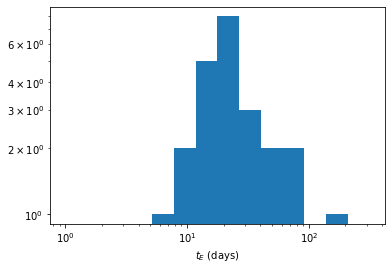

In [13]:
plt.hist(t['t_E'], bins = np.logspace(0, 2.5, 15))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')

## piE vs tE

Text(0, 0.5, '$\\pi_E$')

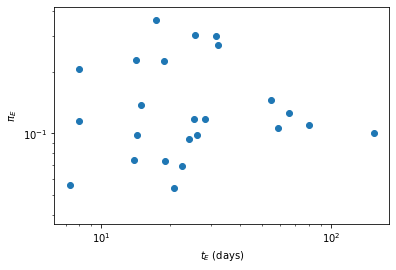

In [14]:
plt.scatter(t['t_E'], t['pi_E'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$t_E$ (days)')
plt.ylabel('$\pi_E$')

## dL vs dS

Text(0, 0.5, '$d_S$ (kpc)')

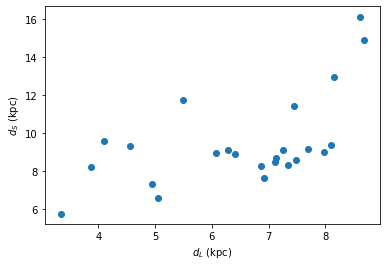

In [15]:
plt.scatter(t['rad_L'], t['rad_S'])
plt.xlabel('$d_L$ (kpc)')
plt.ylabel('$d_S$ (kpc)')